In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import numpy as np
from scipy.stats import hypergeom
import matplotlib.pyplot as plt

(np.float64(7.0),
 array([5, 4, 5, ..., 5, 5, 7]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 np.float64(0.0869))

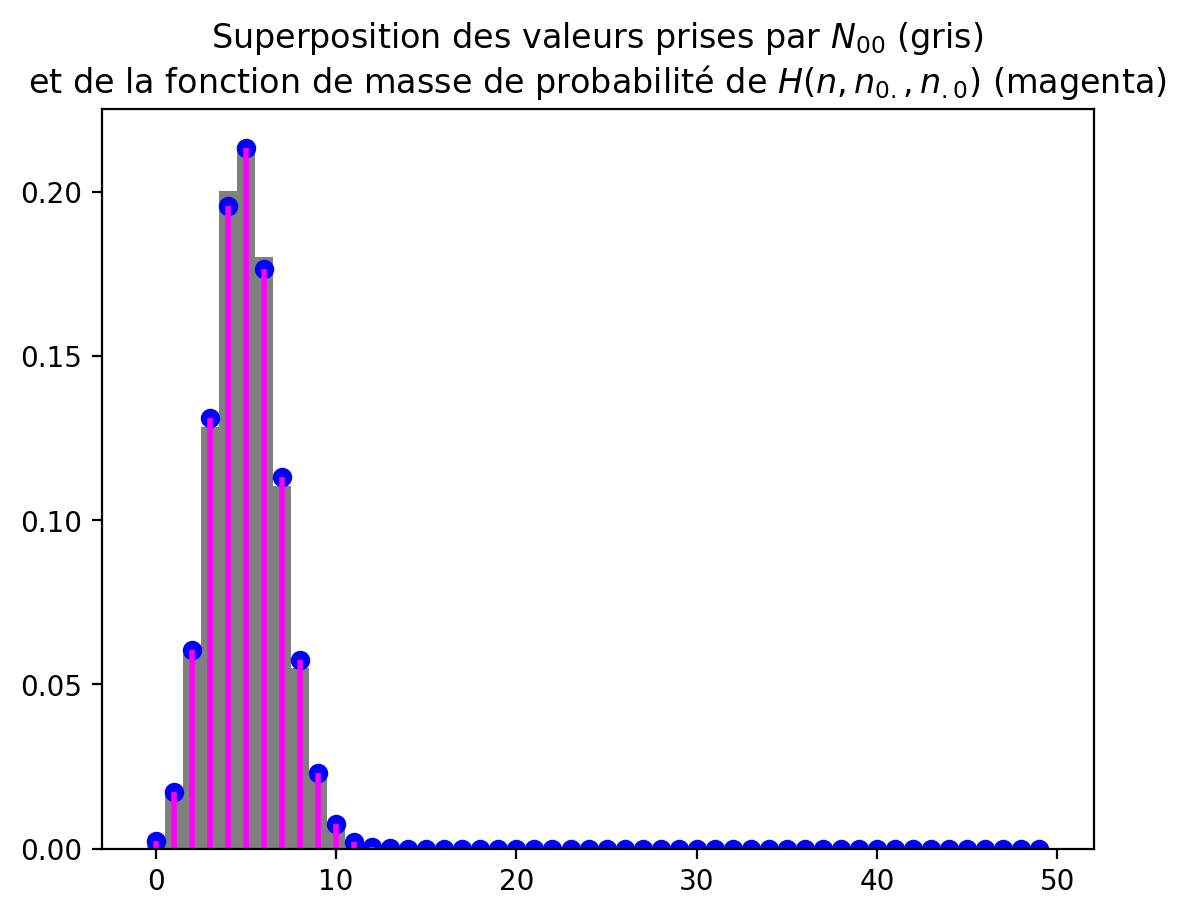

In [56]:
def conditionnal_test_under_null(alpha,n,n0_,n_0,B,plot=True):
    loi= hypergeom(n, n0_,n_0)
    crit=loi.ppf(1-alpha)
    tirages=loi.rvs(size=B)
    res=np.ones(len(tirages))
    for i in range(B):
        if tirages[i]>crit:
            res[i]=1
        else:
            res[i]=0
    if plot:
        k = np.arange(0,max(n0_,n_0))
        pk = loi.pmf(k)
        plt.hist(tirages,density=True,bins=np.arange(min(k),max(k)+2)-0.5,histtype='bar',color="grey")
        plt.plot(k, pk, 'bo')
        plt.vlines(k, 0, pk, lw=2,color="magenta")
    plt.title("Superposition des valeurs prises par $N_{00}$ (gris)\n"
              "et de la fonction de masse de probabilité de $H(n,n_{0.},n_{.0})$ (magenta)")    
    return(crit,tirages,res,(1/B)*sum(res))
            
conditionnal_test_under_null(0.1,200,20,50,10000)

      
        

[[ 0.   10.   20.   30.   40.   50.   60.   70.   80.   90.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.47]]


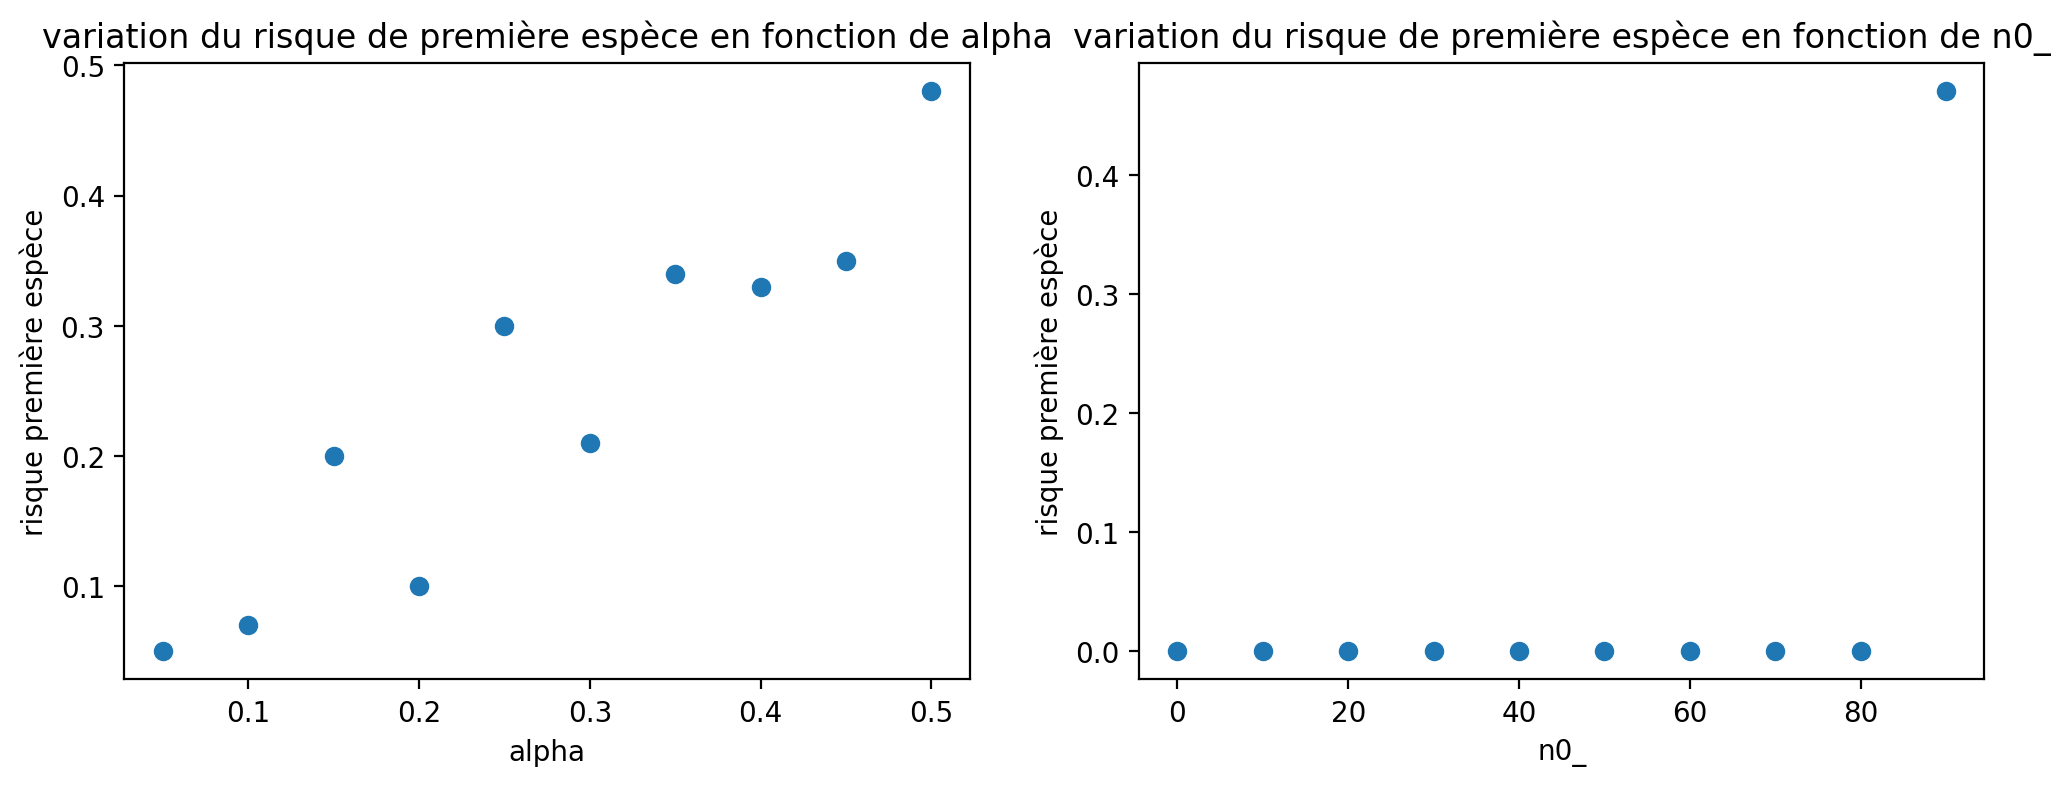

In [52]:
def estimateur_risque_première_espèce(alpha,n,n0_,n_0,B):
    tab=np.zeros((2,10))
    tab1=np.zeros((2,10))
    N0_=np.arange(0,100,10)
    tab1[0,:]=N0_
    for i in range(10):    
        tab[0,i] = alpha      
        tab[1,i] = conditionnal_test_under_null(alpha,n,n0_,n_0,B,plot=False)[3]     
        alpha += 0.05
    for j in range(10):
        tab1[1,i]=conditionnal_test_under_null(alpha,n,N0_[i],n_0,B,plot=False)[3]
        
        
    

    fig=plt.figure(figsize=(12,4))
    ax1=fig.add_subplot(1,2,1)
    ax2=fig.add_subplot(1,2,2)
    ax1.scatter(tab[0,:],tab[1,:])
    ax1.set_title("variation du risque de première espèce en fonction de alpha")
    ax1.set_xlabel("alpha")
    ax1.set_ylabel("risque première espèce")
    ax2.scatter(tab1[0,:],tab1[1,:])
    ax2.set_title("variation du risque de première espèce en fonction de n0_")
    ax2.set_xlabel("n0_")
    ax2.set_ylabel("risque première espèce")
    print(tab1)


estimateur_risque_première_espèce(0.05,200,50,50,100)    